In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.1 MB/s eta 0:00:00


In [3]:
DATA_DIR="/content/drive/MyDrive/drug_repurposing/data"

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pickle

In [5]:
from torch_geometric.nn import HeteroConv, GATConv
from torch_geometric.transforms import ToUndirected
from sklearn.metrics import roc_auc_score, average_precision_score

In [6]:
# DATA_DIR = "data"

checkpoint=torch.load(f"{DATA_DIR}/processed/filtered_graph.pt", weights_only=False)
data=checkpoint["data"]

with open(f"{DATA_DIR}/processed/edge_splits/train_pos.pkl", "rb") as f:
    train_pos = pickle.load(f)

with open(f"{DATA_DIR}/processed/edge_splits/val_pos.pkl", "rb") as f:
    val_pos = pickle.load(f)

with open(f"{DATA_DIR}/processed/negative_samples/train_neg.pkl", "rb") as f:
    train_neg = pickle.load(f)

with open(f"{DATA_DIR}/processed/negative_samples/val_neg.pkl", "rb") as f:
    val_neg = pickle.load(f)

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pickle

In [8]:
from torch_geometric.nn import HeteroConv, GATConv
from torch_geometric.transforms import ToUndirected
from sklearn.metrics import roc_auc_score, average_precision_score

In [9]:
from copy import deepcopy

train_data=deepcopy(data)

train_pos_tensor=torch.tensor(train_pos, dtype=torch.long).t()
train_data[("Compound", "CtD", "Disease")].edge_index = train_pos_tensor

train_data=ToUndirected()(train_data)

In [10]:
EMB_DIM=32
HEADS=4

for node_type in train_data.node_types:
    num_nodes = train_data[node_type].num_nodes
    train_data[node_type].x = nn.Parameter(torch.randn(num_nodes, EMB_DIM))

In [11]:
class HeteroGAT(nn.Module):
    def __init__(self, hidden_dim, heads=4):
        super().__init__()

        self.conv1=HeteroConv(
            {
                edge_type: GATConv(
                    (-1, -1),
                    hidden_dim,
                    heads=heads,
                    concat=True,
                    add_self_loops=False
                )
                for edge_type in train_data.edge_types
            },
            aggr="sum"
        )

        self.conv2=HeteroConv(
            {
                edge_type: GATConv(
                    (-1, -1),
                    hidden_dim,
                    heads=1,
                    concat=False,
                    add_self_loops=False
                )
                for edge_type in train_data.edge_types
            },
            aggr="sum"
        )

    def forward(self, x_dict, edge_index_dict):
      x_dict = self.conv1(x_dict, edge_index_dict)

      x_dict = {
          k: F.dropout(F.elu(v), p=0.5, training=self.training)
          for k, v in x_dict.items()
      }

      x_dict = self.conv2(x_dict, edge_index_dict)

      x_dict = {
          k: F.dropout(v, p=0.3, training=self.training)
          for k, v in x_dict.items()
      }

      return x_dict

In [12]:
def dot_decoder(z_drug, z_disease, edges):
    device=z_drug.device

    drug_idx=torch.tensor(
        [e[0] for e in edges],
        device=device
    )
    disease_idx=torch.tensor(
        [e[1] for e in edges],
        device=device
    )

    scores=(z_drug[drug_idx] * z_disease[disease_idx]).sum(dim=1)
    return scores

In [13]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print("using device:", device)

model = HeteroGAT(EMB_DIM, heads=HEADS).to(device)
train_data = train_data.to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.003,
    weight_decay=1e-4
)

using device: cuda


In [14]:
def train_step(pos_edges, neg_edges):
    model.train()
    optimizer.zero_grad()

    z_output = model(train_data.x_dict, train_data.edge_index_dict)
    # Handle cases where model might return (embeddings, attention_dict)
    if isinstance(z_output, tuple):
        z = z_output[0]
    else:
        z = z_output

    pos_scores = dot_decoder(z["Compound"], z["Disease"], pos_edges)
    neg_scores = dot_decoder(z["Compound"], z["Disease"], neg_edges)

    scores = torch.cat([pos_scores, neg_scores])
    labels = torch.cat([
        torch.ones(len(pos_scores)),
        torch.zeros(len(neg_scores))
    ]).to(device)

    loss = F.binary_cross_entropy_with_logits(scores, labels)
    loss.backward()
    optimizer.step()

    return loss.item()


@torch.no_grad()
def evaluate(pos_edges, neg_edges):
    model.eval()

    z_output = model(train_data.x_dict, train_data.edge_index_dict)
    # Handle cases where model might return (embeddings, attention_dict)
    if isinstance(z_output, tuple):
        z = z_output[0]
    else:
        z = z_output

    pos_scores = dot_decoder(z["Compound"], z["Disease"], pos_edges)
    neg_scores = dot_decoder(z["Compound"], z["Disease"], neg_edges)

    scores = torch.cat([pos_scores, neg_scores]).cpu()
    labels = torch.cat([
        torch.ones(len(pos_scores)),
        torch.zeros(len(neg_scores))
    ])

    auc = roc_auc_score(labels, scores)
    ap = average_precision_score(labels, scores)

    return auc, ap

In [15]:
train_losses = []
val_aucs = []
val_aps = []

best_val_ap = 0
patience = 10
patience_counter = 0

for epoch in range(1, 101):
    loss = train_step(train_pos, train_neg)
    val_auc, val_ap = evaluate(val_pos, val_neg)

    train_losses.append(loss)
    val_aucs.append(val_auc)
    val_aps.append(val_ap)

    print(
        f"Epoch {epoch:03d} | "
        f"Loss: {loss:.4f} | "
        f"Val AUC: {val_auc:.4f} | "
        f"Val AP: {val_ap:.4f}"
    )

    if val_ap > best_val_ap:
        best_val_ap = val_ap
        patience_counter = 0
        torch.save(model.state_dict(), "hetero_gat_best.pt")
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("early stopping triggered")
        break

Epoch 001 | Loss: 5.8643 | Val AUC: 0.6345 | Val AP: 0.6578
Epoch 002 | Loss: 4.1051 | Val AUC: 0.6613 | Val AP: 0.6855
Epoch 003 | Loss: 2.5545 | Val AUC: 0.6872 | Val AP: 0.7129
Epoch 004 | Loss: 2.8962 | Val AUC: 0.7405 | Val AP: 0.7675
Epoch 005 | Loss: 1.9830 | Val AUC: 0.8270 | Val AP: 0.8595
Epoch 006 | Loss: 1.6872 | Val AUC: 0.8829 | Val AP: 0.9102
Epoch 007 | Loss: 1.1357 | Val AUC: 0.9096 | Val AP: 0.9324
Epoch 008 | Loss: 1.1040 | Val AUC: 0.9332 | Val AP: 0.9512
Epoch 009 | Loss: 1.1365 | Val AUC: 0.9443 | Val AP: 0.9614
Epoch 010 | Loss: 0.7170 | Val AUC: 0.9460 | Val AP: 0.9610
Epoch 011 | Loss: 0.7536 | Val AUC: 0.9437 | Val AP: 0.9596
Epoch 012 | Loss: 0.8349 | Val AUC: 0.9443 | Val AP: 0.9600
Epoch 013 | Loss: 0.5771 | Val AUC: 0.9430 | Val AP: 0.9596
Epoch 014 | Loss: 0.5678 | Val AUC: 0.9411 | Val AP: 0.9586
Epoch 015 | Loss: 0.4559 | Val AUC: 0.9396 | Val AP: 0.9588
Epoch 016 | Loss: 0.4766 | Val AUC: 0.9388 | Val AP: 0.9585
Epoch 017 | Loss: 0.2803 | Val AUC: 0.93

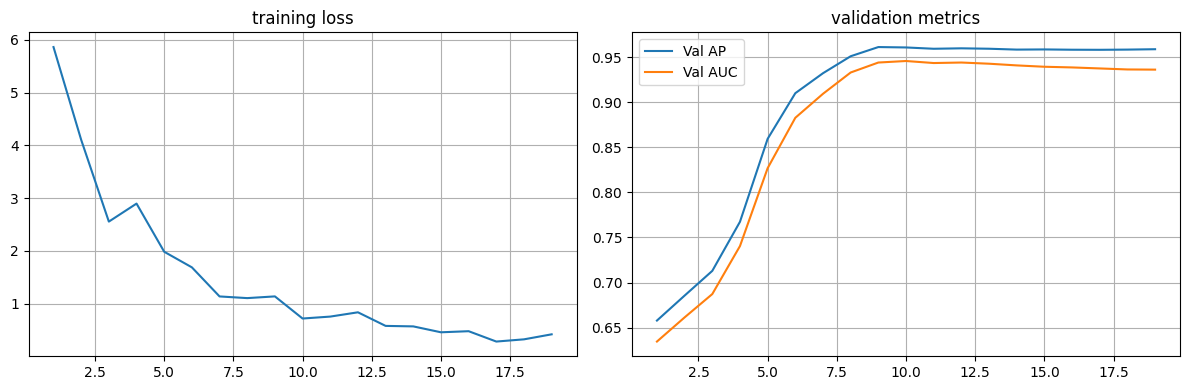

In [16]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses)
plt.title("training loss")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, val_aps, label="Val AP")
plt.plot(epochs, val_aucs, label="Val AUC")
plt.title("validation metrics")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [17]:
with open(f"{DATA_DIR}/processed/edge_splits/test_pos.pkl", "rb") as f:
    test_pos = pickle.load(f)

with open(f"{DATA_DIR}/processed/negative_samples/test_neg.pkl", "rb") as f:
    test_neg = pickle.load(f)

model.load_state_dict(torch.load("hetero_gat_best.pt"))

test_auc, test_ap = evaluate(test_pos, test_neg)

print(f"Test AUC: {test_auc:.4f}")
print(f"Test AP: {test_ap:.4f}")

Test AUC: 0.9299
Test AP: 0.9198


In [18]:
from torch_geometric.nn import HeteroConv, GATConv

class HeteroGAT_Attn(nn.Module):
    def __init__(self, hidden_dim, heads=4):
        super().__init__()

        self.conv1 = HeteroConv(
            {
                edge_type: GATConv(
                    (-1, -1),
                    hidden_dim,
                    heads=heads,
                    concat=True,
                    add_self_loops=False
                )
                for edge_type in train_data.edge_types
            },
            aggr="sum"
        )

        self.conv2 = HeteroConv(
            {
                edge_type: GATConv(
                    (-1, -1),
                    hidden_dim,
                    heads=1,
                    concat=False,
                    add_self_loops=False
                )
                for edge_type in train_data.edge_types
            },
            aggr="sum"
        )

    def forward(self, x_dict, edge_index_dict):

        out_dict = {}
        attention_dict = {}

        # Manually compute attention for conv1
        for edge_type, conv in self.conv1.convs.items():
            src_type, _, dst_type = edge_type

            x_src = x_dict[src_type]
            x_dst = x_dict[dst_type]
            edge_index = edge_index_dict[edge_type]

            out, (ei, alpha) = conv(
                (x_src, x_dst),
                edge_index,
                return_attention_weights=True
            )

            if dst_type not in out_dict:
                out_dict[dst_type] = out
            else:
                out_dict[dst_type] += out

            attention_dict[edge_type] = alpha.detach().cpu()

        # Apply activation + dropout
        for k in out_dict:
            out_dict[k] = F.dropout(F.elu(out_dict[k]), p=0.5, training=False)

        # Second layer normally
        out_dict = self.conv2(out_dict, edge_index_dict)

        return out_dict, attention_dict

In [19]:
attn_model = HeteroGAT_Attn(EMB_DIM, heads=HEADS).to(device)
attn_model.load_state_dict(torch.load("hetero_gat_best.pt"))
attn_model.eval()

print("Attention-enabled model loaded.")

Attention-enabled model loaded.


In [20]:
with torch.no_grad():
    _, attention_dict = attn_model(
        train_data.x_dict,
        train_data.edge_index_dict
    )

print("Attention extracted for relations:")
print(attention_dict.keys())

Attention extracted for relations:
dict_keys([('Compound', 'CtD', 'Disease'), ('Gene', 'GiG', 'Gene'), ('Disease', 'DdG', 'Gene'), ('Compound', 'CbG', 'Gene'), ('Compound', 'CuG', 'Gene'), ('Disease', 'DaG', 'Gene'), ('Gene', 'GcG', 'Gene'), ('Gene', 'Gr>G', 'Gene'), ('Compound', 'CdG', 'Gene'), ('Disease', 'DuG', 'Gene'), ('Disease', 'rev_CtD', 'Compound'), ('Gene', 'rev_DdG', 'Disease'), ('Gene', 'rev_CbG', 'Compound'), ('Gene', 'rev_CuG', 'Compound'), ('Gene', 'rev_DaG', 'Disease'), ('Gene', 'rev_CdG', 'Compound'), ('Gene', 'rev_DuG', 'Disease')])


In [21]:
relation_attention = {}

for edge_type, alpha in attention_dict.items():
    mean_attention = alpha.mean().item()
    relation_attention[edge_type] = mean_attention

for rel, score in sorted(
    relation_attention.items(),
    key=lambda x: x[1],
    reverse=True
):
    print(f"{rel}: {score:.4f}")

('Disease', 'DdG', 'Gene'): 0.7536
('Disease', 'DuG', 'Gene'): 0.7282
('Disease', 'DaG', 'Gene'): 0.4272
('Disease', 'rev_CtD', 'Compound'): 0.3588
('Compound', 'CuG', 'Gene'): 0.1731
('Compound', 'CtD', 'Disease'): 0.1676
('Compound', 'CbG', 'Gene'): 0.1460
('Compound', 'CdG', 'Gene'): 0.1365
('Gene', 'rev_CbG', 'Compound'): 0.1200
('Gene', 'GcG', 'Gene'): 0.1009
('Gene', 'GiG', 'Gene'): 0.0515
('Gene', 'rev_CuG', 'Compound'): 0.0375
('Gene', 'rev_CdG', 'Compound'): 0.0348
('Gene', 'Gr>G', 'Gene'): 0.0164
('Gene', 'rev_DaG', 'Disease'): 0.0106
('Gene', 'rev_DdG', 'Disease'): 0.0058
('Gene', 'rev_DuG', 'Disease'): 0.0057


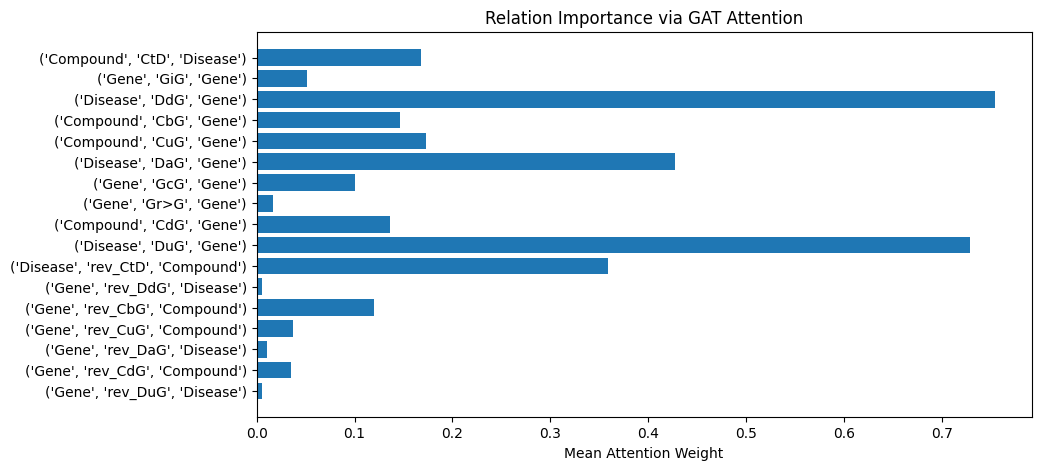

In [22]:
import matplotlib.pyplot as plt

relations = [str(r) for r in relation_attention.keys()]
scores = list(relation_attention.values())

plt.figure(figsize=(10, 5))
plt.barh(relations, scores)
plt.xlabel("Mean Attention Weight")
plt.title("Relation Importance via GAT Attention")
plt.gca().invert_yaxis()
plt.show()

In [23]:
import torch

# -------- Safe Embedding Extraction --------
@torch.no_grad()
def extract_embeddings(model, data):
    model.eval()

    output = model(data.x_dict, data.edge_index_dict)

    # Handle both cases:
    # - model returns z_dict
    # - model returns (z_dict, attention_dict)
    if isinstance(output, tuple):
        z = output[0]
    else:
        z = output

    return {
        "Compound": z["Compound"].cpu(),
        "Disease": z["Disease"].cpu(),
        "Gene": z["Gene"].cpu()
    }

# Extract embeddings
embeddings = extract_embeddings(model, train_data)

# -------- Build Artifact --------
gat_artifact = {
    "model_name": "HeteroGAT_regularized",
    "embedding_dim": EMB_DIM,
    "heads": HEADS,
    "dropout_layer1": 0.5,
    "dropout_layer2": 0.3,
    "weight_decay": 5e-4,
    "best_val_auc": max(val_aucs),
    "best_val_ap": max(val_aps),
    "test_auc": test_auc,
    "test_ap": test_ap,
    "train_losses": train_losses,
    "val_aucs": val_aucs,
    "val_aps": val_aps,
    "relation_attention": relation_attention,
    "embeddings": embeddings
}

# -------- Save --------
torch.save(gat_artifact, "hetero_gat_artifact.pt")

print("GAT artifact saved to hetero_gat_artifact.pt")

GAT artifact saved to hetero_gat_artifact.pt


In [24]:
!find /content/drive -name "hetero_gat_artifact.pt"

In [25]:
!find /content -name "hetero_gat_artifact.pt"

/content/hetero_gat_artifact.pt


In [28]:
SAVE_PATH = "/content/drive/MyDrive/drug_repurposing/models/"
torch.save(gat_artifact, SAVE_PATH + "hetero_gat_artifact.pt")